In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
df.info()
df.head()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


🌟 Exercise 1: Duplicate Detection and Removal

In [145]:
#Identify if there are any duplicate rows based on all columns.
df.duplicated() #Montre s'il y'a des doublons
nombre_de_lignes_before = df.shape[0]
#Remove any duplicate rows found in the dataset.
df.drop_duplicates(inplace=True)
nombre_de_lignes_after = df.shape[0]
print(f"Nombre de lignes avant drop.duplicates: {nombre_de_lignes_before}" )
print(f"Nombre de lignes après drop.duplicates: {nombre_de_lignes_after}" )


Nombre de lignes avant drop.duplicates: 889
Nombre de lignes après drop.duplicates: 889


🌟 Exercise 2: Handling Missing Values

In [126]:
# from sklearn.impute import KNNImputer

# imputer = KNNImputer(n_neighbors=2)

#Remplace les valeurs manquantes dans cette colonne par sa moyenne. 
# Il est impossiple de faire ça pour les autres colonnes car elles sont catégorielles

#Imputation 
# print(df.isnull().sum())
# df['Age'] = df['Age'].fillna(df['Age'].mean())
#knn imputer
# df['Age'] = imputer.fit_transform(df[['Age']])
#removal
# df = df.dropna(subset=['Embarked'])
#fillna()
# df['Cabin'] = df['Cabin'].fillna('Inconnu')


In [139]:
missing_values = df.isnull().sum()
print("Valeurs manquantes initiales :")
print(missing_values)
print("-" * 40)
df_cleaned = df
df_cleaned.dropna(subset=['Embarked'], inplace=True)
df_cleaned['Cabin'].fillna('Inconnu', inplace=True)
df_cleaned['Age'].fillna(df_cleaned['Age'].mean(), inplace=True)
print("Valeurs manquantes après correction :")
print(df_cleaned[['Embarked', 'Cabin', 'Age']].isnull().sum())

Valeurs manquantes initiales :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------------------------------------
Valeurs manquantes après correction :
Embarked    0
Cabin       0
Age         0
dtype: int64


🌟 Exercise 3: Feature Engineering

In [146]:
from sklearn.preprocessing import OneHotEncoder

#Create new features, such as Family Size from SibSp and Parch, and Title extracted from the Name column.
#Création d'une nouvelle colonne(taille de la famille ) en additionnant les colonnes montrant le nombre d'enfants et de conjoint + 1
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df.head()
#Extraction du titre de chaque passager. Comment? On a identifié où les titres se situent, le point commun de chaque; la règle à laquelle
#ils obéissent tous et l'avons utilisée pour les cibler.
df['Title'] = df['Name'].str.split(', ').str[1].str.split('.').str[0]
#print(df['Family_Size'])
#Encodage des valeurs Catégorielles
encoder = OneHotEncoder(sparse_output=False)
df['Title'] = encoder.fit_transform(df[['Title']])
#print(f"Title Encoded: {title_encoded}")

🌟 Exercise 4: Outlier Detection and Handling

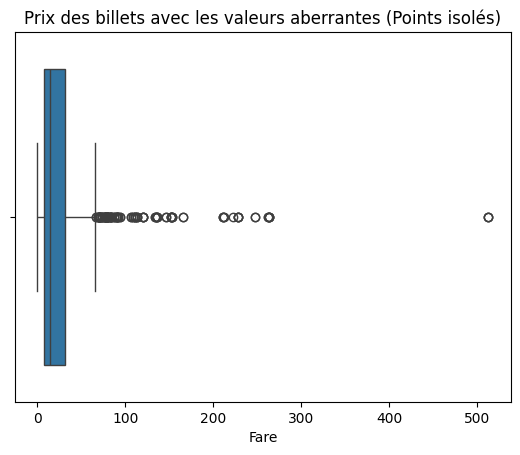

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=df['Fare'])
plt.title("Prix des billets avec les valeurs aberrantes (Points isolés)")
plt.show()

In [130]:
# 2. On calcule la limite mathématique (méthode IQR) pour savoir à partir de quel prix c'est "anormal"
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
limite_haute = Q3 + 1.5 * IQR
print(f"Tous les billets au-dessus de {limite_haute}$ sont des valeurs aberrantes.")

Tous les billets au-dessus de 65.6563$ sont des valeurs aberrantes.


In [131]:
# 3. On trouve la valeur plafond (le prix au 98ème centile)
plafond_98 = df['Fare'].quantile(0.98)

# On applique le plafond : tout ce qui dépasse 'plafond_98' est rabaissé à cette valeur
df['Fare'] = df['Fare'].clip(upper=plafond_98)

In [132]:
#Avec rax removal
#df_sans_outliers = df[df['Fare'] <= limite_haute]

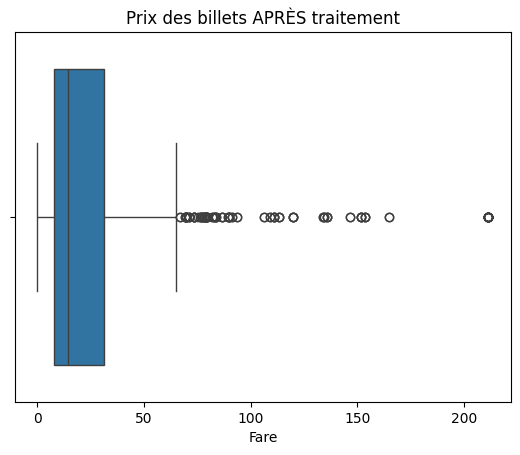

In [133]:
sns.boxplot(x=df['Fare'])
plt.title("Prix des billets APRÈS traitement")
plt.show()

🌟 Exercise 5: Data Standardization and Normalization

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. On crée des copies de nos scalers
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# 2. Application du StandardScaler sur la colonne normale (Age)
# Note : On utilise double crochet [['Age']] car le scaler attend un tableau en 2D
df['Age'] = scaler_standard.fit_transform(df[['Age']])

# 3. Application du MinMaxScaler sur les colonnes asymétriques ou bornées (Fare, Family_Size)
df['Fare'] = scaler_minmax.fit_transform(df[['Fare']])

# Si vous avez créé la variable Family_Size à l'exercice 3 :
df['Family_Size'] = scaler_minmax.fit_transform(df[['Family_Size']])

🌟 Exercise 6: Feature Encoding
Goal: Finalize categorical variable encoding.

1. Identify remaining categorical columns (e.g. Sex, Embarked, Title).
2. Apply:

One-Hot Encoding for nominal variables.
Label Encoding if any ordinal variables remain. #Rien de tel dans le dtaset"
3. Merge encoded columns back into the main dataset.

📌 Reminder: Encoding comes after handling missing values and outliers, but before scaling (if applicable).

In [140]:
df_cleaned.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Inconnu,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Inconnu,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Inconnu,S


In [150]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
df_cleaned['Sex']= encoder.fit_transform(df_cleaned[['Sex']])
df_cleaned['Embarked']= encoder.fit_transform(df_cleaned[['Embarked']])
df_cleaned.head()
# df_final = pd.get_dummies(df_cleaned, columns=["Sex", "Embarked"])
# df_final.head()   

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",0.0,22.0,1,0,A/5 21171,7.2500,Inconnu,0.0,Adulte
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1.0,38.0,1,0,PC 17599,71.2833,C85,1.0,Adulte
2,3,1,3,"Heikkinen, Miss. Laina",1.0,26.0,0,0,STON/O2. 3101282,7.9250,Inconnu,0.0,Adulte
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1.0,35.0,1,0,113803,53.1000,C123,0.0,Adulte
4,5,0,3,"Allen, Mr. William Henry",0.0,35.0,0,0,373450,8.0500,Inconnu,0.0,Adulte


🌟 Exercise 7: Data Transformation for Age Feature

In [144]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 100], labels=['Enfant', 'Ado', 'Adulte', 'Senior'])
df = pd.get_dummies(df, columns=['Age_Group'])